In [9]:
# used to improve models accuracy by eliminating features.

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [23]:
dataset = pd.read_csv(r"./data/housepricing(Regularization).csv")
dataset.head(4)

,price,bedrooms,sqft_living,sqft_lot,floors,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city
0,313000.0,3,1340,7912,1.5,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline
1,2384000.0,5,3650,9050,2.0,4,5,3370,280,1921,0,709 W Blaine St,Seattle
2,342000.0,3,1930,11947,1.0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent
3,420000.0,3,2000,8030,1.0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue


In [24]:
dataset.drop(["street", "city"], axis=1, inplace=True)

In [25]:
dataset.head(3)

,price,bedrooms,sqft_living,sqft_lot,floors,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
0,313000.0,3,1340,7912,1.5,0,3,1340,0,1955,2005
1,2384000.0,5,3650,9050,2.0,4,5,3370,280,1921,0
2,342000.0,3,1930,11947,1.0,0,4,1930,0,1966,0


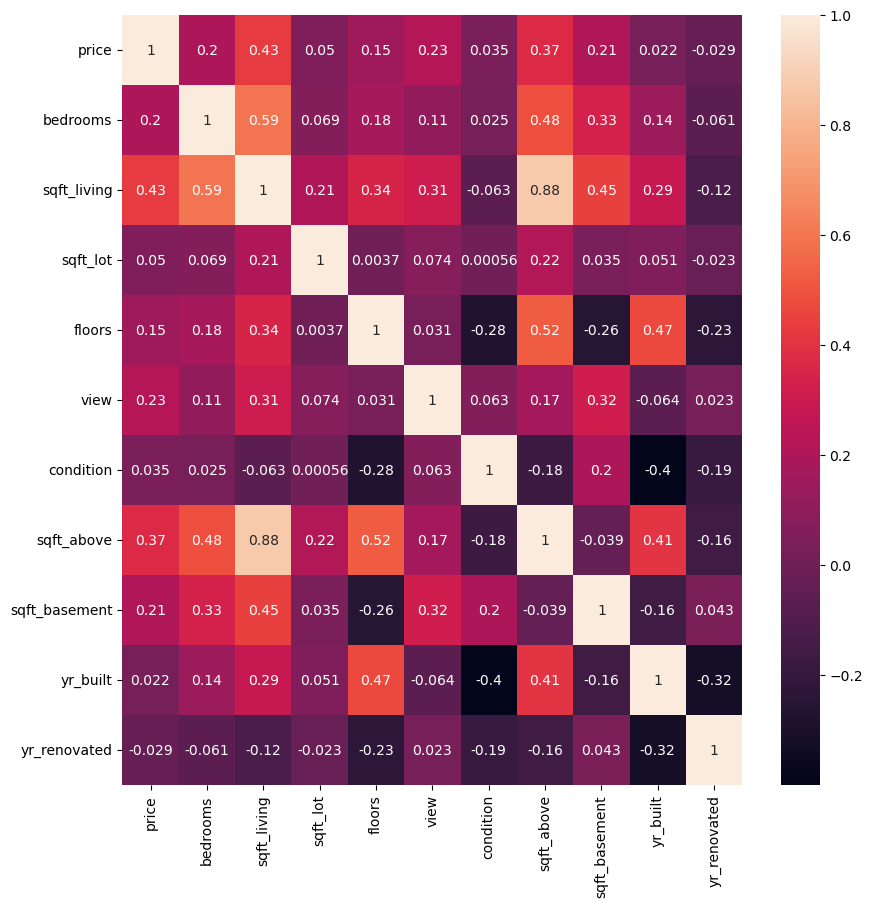

In [27]:
plt.figure(figsize=(10,10))
sns.heatmap(data=dataset.corr(), annot=True)
plt.show()

In [35]:
x = dataset.iloc[:, 1:]
y = dataset['price']

In [39]:
sc = StandardScaler()
sc.fit(x)
x = pd.DataFrame(sc.transform(x), columns=x.columns)

In [40]:
x

,bedrooms,sqft_living,sqft_lot,floors,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
0,-0.441122,-0.829971,-0.193434,-0.022416,-0.309194,-0.667112,-0.565224,-0.672464,-0.531014,1.221670
1,1.759705,1.568528,-0.161718,0.906555,4.830079,2.286416,1.789559,-0.069128,-1.674693,-0.825693
2,-0.441122,-0.217367,-0.080978,-0.951388,-0.309194,0.809652,0.119171,-0.672464,-0.161000,-0.825693
3,-0.441122,-0.144686,-0.190145,-0.951388,-0.309194,0.809652,-0.959621,1.482306,-0.261913,-0.825693
4,0.659291,-0.206984,-0.121306,-0.951388,-0.309194,0.809652,-0.797222,1.051352,0.175376,1.208396
...,...,...,...,...,...,...,...,...,...,...
4595,-0.441122,-0.653458,-0.236689,-0.951388,-0.309194,0.809652,-0.368025,-0.672464,-0.564651,1.195121
4596,-0.441122,-0.705374,-0.202882,0.906555,-0.309194,-0.667112,-0.426025,-0.672464,0.410840,1.225755
4597,-0.441122,0.904009,-0.218462,0.906555,-0.309194,-0.667112,1.371962,-0.672464,1.285418,-0.825693
4598,0.659291,-0.051238,-0.229164,-0.951388,-0.309194,-0.667112,-0.878421,1.525401,0.108101,-0.825693


In [42]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [68]:
from sklearn.linear_model import LinearRegression, Lasso, Ridge

In [71]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Linear Regression

In [72]:
lr = LinearRegression()

In [73]:
lr.fit(x_train, y_train)

LinearRegression()

In [74]:
lr.score(x_test, y_test) * 100

3.028962541122804

In [77]:
print(mean_squared_error(y_test, lr.predict(x_test)))
print(mean_absolute_error(y_test, lr.predict(x_test)))

# root mean squared error
print(np.sqrt(mean_squared_error(y_test, lr.predict(x_test))))

988955576468.7089
212199.1926709529
994462.4560377877


In [49]:
lr.coef_

array([-57079.75820326, 146624.27145509, -19058.18161704,  44032.89818925,
        46733.97923234,  19520.9264045 , 127007.93739611,  68357.38853608,
       -70978.67536908,   7469.03812177])

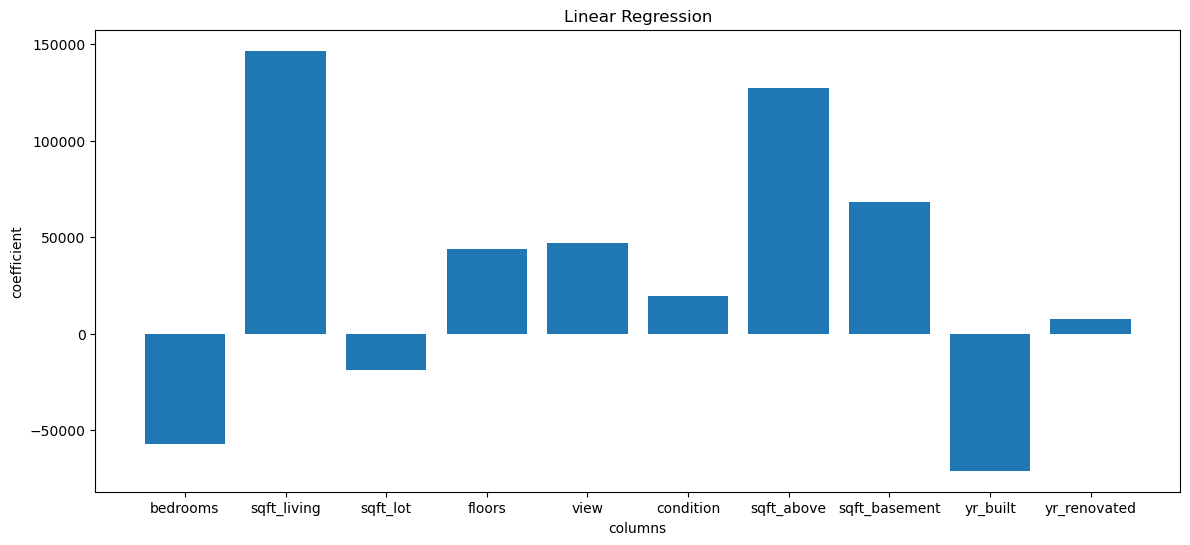

In [57]:
plt.figure(figsize=(14, 6))
plt.bar(x.columns, lr.coef_)
plt.title("Linear Regression")
plt.xlabel("columns")
plt.ylabel("coefficient")
plt.show()

# Lasso (L1)

In [61]:
# alpha = penalty

la = Lasso(alpha=10)
la.fit(x_train, y_train)
la.score(x_test, y_test) * 100

/home/satyajit-sahoo/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.090e+13, tolerance: 5.229e+10
  model = cd_fast.enet_coordinate_descent(


3.0287862300973356

In [78]:
print(mean_squared_error(y_test, la.predict(x_test)))
print(mean_absolute_error(y_test, la.predict(x_test)))

# root mean squared error
print(np.sqrt(mean_squared_error(y_test, la.predict(x_test))))

988957374570.2493
212199.91934804994
994463.3600944025


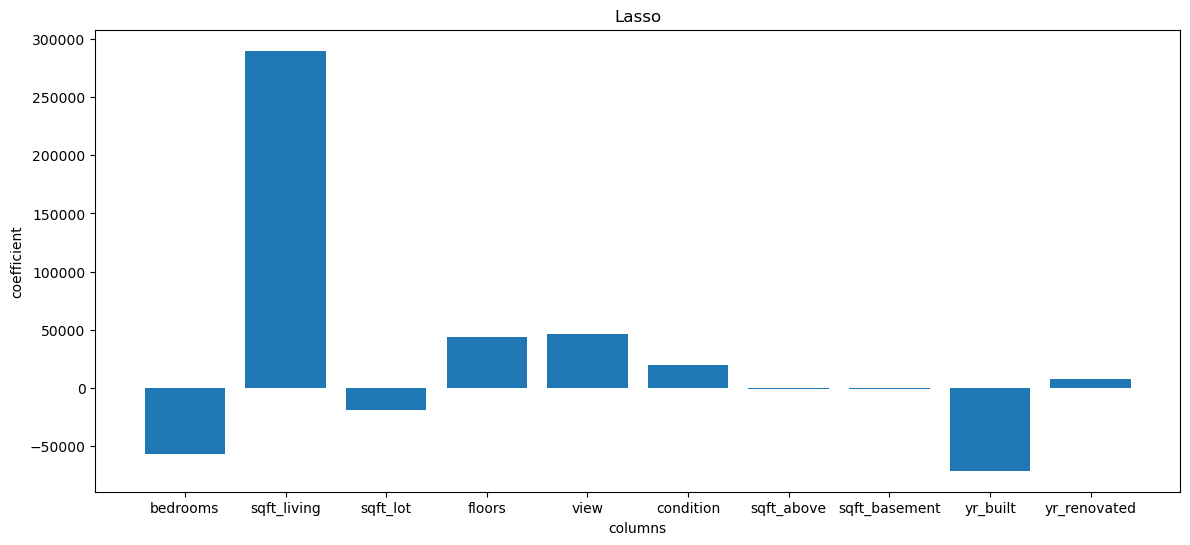

In [63]:
plt.figure(figsize=(14, 6))
plt.bar(x.columns, la.coef_)
plt.title("Lass")
plt.xlabel("columns")
plt.ylabel("coefficient")
plt.show()

# Ridge (L2)

In [66]:
ri = Ridge(alpha=10)
ri.fit(x_train, y_train)
ri.score(x_test, y_test)*100

3.0403641033112105

In [79]:
print(mean_squared_error(y_test, ri.predict(x_test)))
print(mean_absolute_error(y_test, ri.predict(x_test)))

# root mean squared error
print(np.sqrt(mean_squared_error(y_test, ri.predict(x_test))))

988839298054.0177
212108.8299157823
994403.9913707194


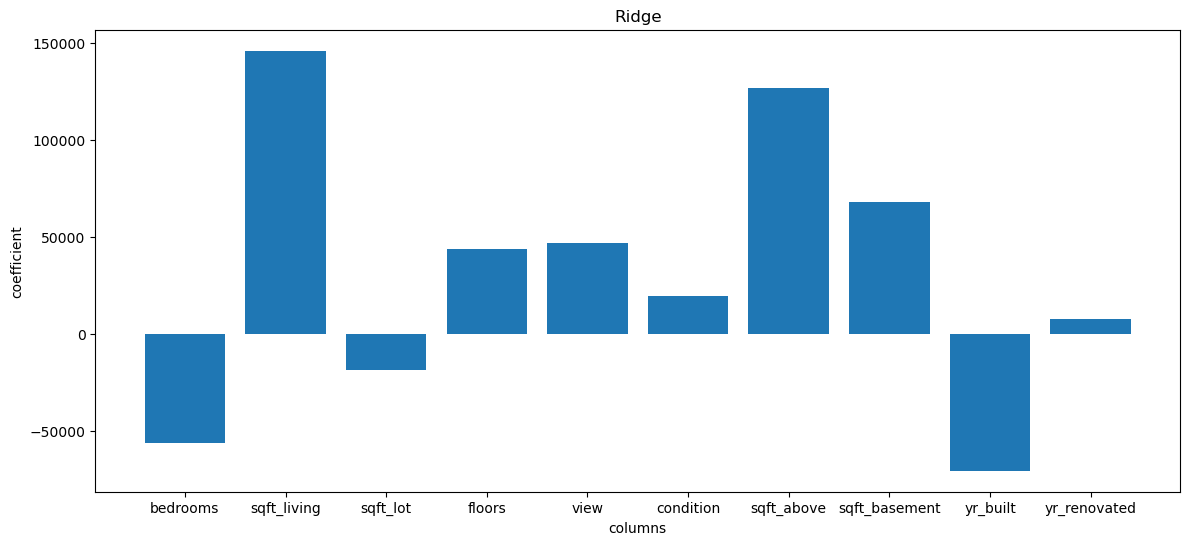

In [67]:
plt.figure(figsize=(14, 6))
plt.bar(x.columns, ri.coef_)
plt.title("Ridge")
plt.xlabel("columns")
plt.ylabel("coefficient")
plt.show()

In [ ]:
df = pd.DataFrame({"col_name": x.columns, "LinearRegression": lr.coef_, "Lasso": la.coef_, "Ridge":  })